In [ ]:
import pickle

#Define the file path (replace 'data.pkl' with your actual file name/path)
file_path = 'aw_ecg_export.pkl'

try:
    # Open the file in binary read mode ('rb')
    with open(file_path, 'rb') as f:
        # Load the data from the file
        data = pickle.load(f)

    # Now you can use the loaded data
    print("Data successfully loaded.")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except pickle.UnpicklingError:
    print(f"Error: Could not unpickle the data from '{file_path}'. Check file integrity.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Data successfully loaded.


C:\Users\lily\AppData\Local\Temp\ipykernel_20584\452132532.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


In [ ]:
import pandas as pd

df = pd.DataFrame(data)
df.head(10)
df["date"] = pd.to_datetime(df["date"], utc=True)
df["date"] = df["date"].dt.tz_localize(None)
df.to_excel("ECG.xlsx", index=False)
df.to_csv("ECG_data_export.csv", index=False)

In [ ]:
import os
output_dir = "ecg_plots"
os.makedirs(output_dir, exist_ok=True)

for pseudonym, group in df.groupby("pseudonym"):
    
    n = len(group)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3*n), sharex=True)
    
    if n == 1:
        axes = [axes]
    
    for ax, (_, row) in zip(axes, group.iterrows()):
        signal = row["ecg"]
        fs = row["fs_in"]
        
        t = np.arange(len(signal)) / fs
        
        ax.plot(t, signal)
        ax.set_ylabel("ECG (nu)")
        ax.grid(True)
        axes[-1].set_xlabel("Time (seconds)")
    fig.suptitle(f"Pseudonym: {pseudonym}", fontsize=14)
    
    plt.tight_layout()
    
    safe_name = str(pseudonym).replace(" ", "_")
    filepath = os.path.join(output_dir, f"{safe_name}.png")
    
    plt.savefig(filepath, dpi=300)
    plt.close(fig)

All ECG plots saved successfully.


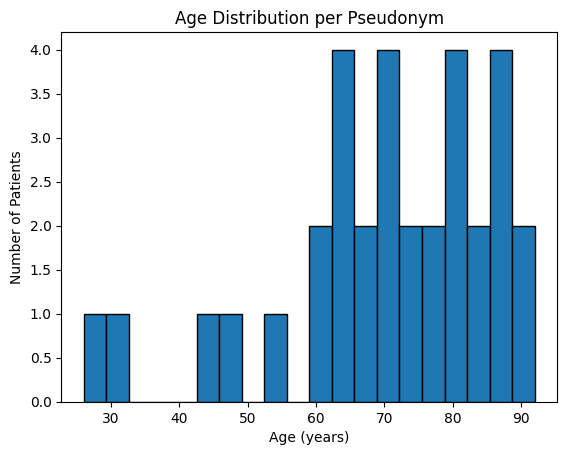

In [28]:
plt.hist(age_per_patient, bins=20, edgecolor="black")
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")
plt.title("Age Distribution per Pseudonym")
plt.show()

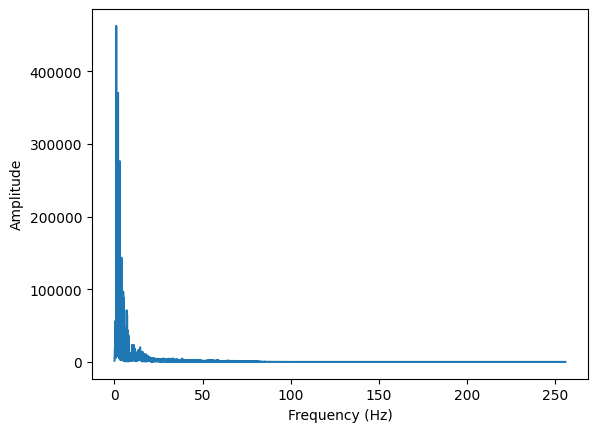

In [ ]:
from scipy.fft import fft

signal = df["ecg"][0]
fs = df["fs_in"][0]

freq = np.fft.fftfreq(len(signal), 1/fs)
spectrum = np.abs(np.fft.fft(signal))

plt.plot(freq[:len(freq)//2], spectrum[:len(freq)//2])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()